In [ ]:
This notebook contains a short analysis of the drone detection dataset used in the project.

In [ ]:
from pathlib import Path

DATASET_PATH = Path("../data/processed")

for split in ["train", "valid", "test"]:
    images = list((DATASET_PATH / split / "images").glob("*"))
    labels = list((DATASET_PATH / split / "labels").glob("*.txt"))
    print(split)
    print("images:", len(images))
    print("labels:", len(labels))
    print()

PREPARING DATASET SPLIT
==================================================
Total images: 9000
Train: 6300
Valid: 1800
Test: 900

The dataset was prepared in YOLO format and split into train, validation and test sets.

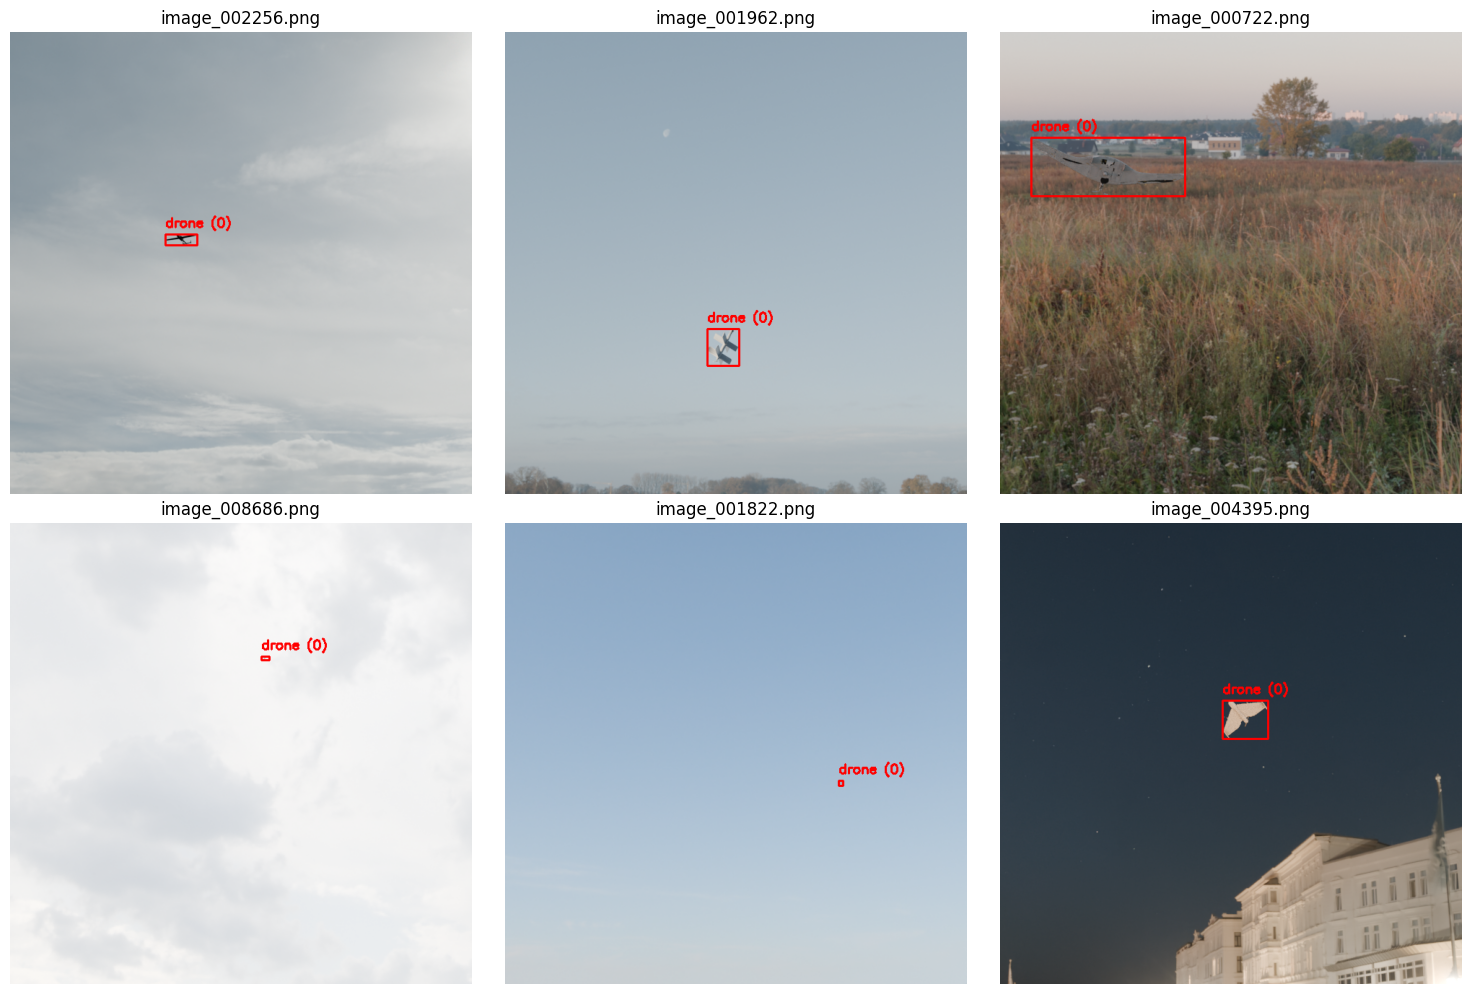

In [3]:
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt


DATASET_ROOT = Path("../data/processed")
SPLIT = "train"   # можна буде змінити на valid або test
NUM_SAMPLES = 6   # скільки картинок показати

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def load_yolo_labels(label_path):
    boxes = []

    if not label_path.exists():
        return boxes

    with open(label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()

        if len(parts) != 5:
            continue

        class_id, x_center, y_center, width, height = map(float, parts)
        boxes.append((int(class_id), x_center, y_center, width, height))

    return boxes


def yolo_to_xyxy(box, img_width, img_height):
    class_id, x_center, y_center, width, height = box

    x_center *= img_width
    y_center *= img_height
    width *= img_width
    height *= img_height

    x1 = int(x_center - width / 2)
    y1 = int(y_center - height / 2)
    x2 = int(x_center + width / 2)
    y2 = int(y_center + height / 2)

    return class_id, x1, y1, x2, y2


def main():
    images_dir = DATASET_ROOT / SPLIT / "images"
    labels_dir = DATASET_ROOT / SPLIT / "labels"

    if not images_dir.exists():
        print(f"ERROR: images folder not found: {images_dir}")
        return

    if not labels_dir.exists():
        print(f"ERROR: labels folder not found: {labels_dir}")
        return

    image_files = [
        f for f in images_dir.iterdir()
        if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
    ]

    if len(image_files) == 0:
        print("ERROR: no images found.")
        return

    sample_files = random.sample(image_files, min(NUM_SAMPLES, len(image_files)))

    plt.figure(figsize=(15, 10))

    for i, img_path in enumerate(sample_files, 1):
        label_path = labels_dir / f"{img_path.stem}.txt"

        image = cv2.imread(str(img_path))
        if image is None:
            print(f"WARNING: could not read image {img_path}")
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        img_h, img_w = image.shape[:2]

        boxes = load_yolo_labels(label_path)

        for box in boxes:
            class_id, x1, y1, x2, y2 = yolo_to_xyxy(box, img_w, img_h)

            cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(
                image,
                f"drone ({class_id})",
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 0),
                2
            )

        plt.subplot(2, 3, i)
        plt.imshow(image)
        plt.title(img_path.name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

The dataset contains annotated drone images. The bounding boxes are used to train YOLO models for drone detection.

In [4]:
from pathlib import Path

DATASET_PATH = Path("../data/processed")

for split in ["train", "valid", "test"]:
    images = list((DATASET_PATH / split / "images").glob("*"))
    labels = list((DATASET_PATH / split / "labels").glob("*.txt"))
    print(split)
    print("images:", len(images))
    print("labels:", len(labels))
    print()

train
images: 8738
labels: 8738

valid
images: 3227
labels: 3227

test
images: 1719
labels: 1719

